In [9]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import Lasso

In [10]:
insurance_data=pd.read_csv("insurance.csv")
insurance_data=pd.get_dummies(insurance_data,columns=["region"],drop_first=False,dtype=int)

x_data=insurance_data.drop(columns=["charges"])
x_data["sex"]=x_data["sex"].map({"female":1,"male":0})
x_data["smoker"]=x_data["smoker"].map({"yes":1,"no":0})

y_data=insurance_data["charges"]

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x_data,y_data,test_size=.20,random_state=42)

In [27]:
alphas=[0.00000001,0.0001,0.0002,0.005,0.007,0.01]
mses=[]
for a in alphas:
    lasso_model=Lasso(alpha=a )
    lasso_model.fit(x_train,y_train)
    y_pred=lasso_model.predict(x_test)
    mse=mean_squared_error(y_test,y_pred)
    mses.append(mse)
print(mses)


[33596915.851387896, 33596916.115689605, 33596916.379894555, 33596929.20918466, 33596934.49368146, 33596942.420685925]


<Axes: >

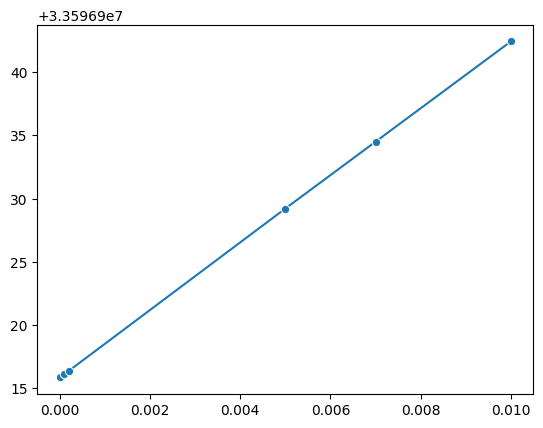

In [28]:
import seaborn as sns
sns.lineplot(x=alphas,y=mses,marker="o")